In [1]:
import glob
import os
os.chdir('..')

In [2]:
import pandas as pd
import numpy as np
import geopandas as gpd

# 1. Import

In [3]:
# Path to the data folder
folder = 'data/raw'

# Define the common
source_name = 'udalmap'

# Use glob to find all the filepaths that start with "udalmap"
filepaths = glob.glob(os.path.join(folder, source_name) + '*.csv')
print(filepaths)

['data/raw\\udalmap-aging.csv', 'data/raw\\udalmap-childhood.csv', 'data/raw\\udalmap-construction-employment.csv', 'data/raw\\udalmap-first_sector-employment.csv', 'data/raw\\udalmap-industry-employment.csv', 'data/raw\\udalmap-ocupation_rate.csv', 'data/raw\\udalmap-passenger_cars.csv', 'data/raw\\udalmap-personal_income.csv', 'data/raw\\udalmap-PIB.csv', 'data/raw\\udalmap-population.csv', 'data/raw\\udalmap-services-employment.csv', 'data/raw\\udalmap-super_aging.csv']


In [4]:
## Import the establishments datasets into a single DataFrame
df_list = []
for filepath in filepaths:
    path = os.path.abspath(filepath)
    file_name = os.path.basename(filepath) # get only the file name without the path
    description = file_name.replace(source_name, '').replace('-', '').replace('.csv', '') # get the description of the data
    data = pd.read_csv(path, sep=',', decimal='.', index_col=0, encoding='utf-8')
    print(f'The file {path} has been imported')
    
    data = data.rename_axis('Municipality').reset_index()
    id_vars = ['Municipality']
    value_vars = [col for col in data.columns if col not in id_vars]
    data = pd.melt(data, id_vars = id_vars, value_vars=value_vars, var_name='Year', value_name='Value')
    data['Variable'] = description
    
    df_list.append(data) # add the processed data to the list
    
# Concatenate all the datasets from udalmap
df_combined = pd.concat(df_list, axis=0, join='inner')
    
df_combined

The file c:\Users\narronizari\OneDrive - ---\Escritorio\phd-research\data\raw\udalmap-aging.csv has been imported
The file c:\Users\narronizari\OneDrive - ---\Escritorio\phd-research\data\raw\udalmap-childhood.csv has been imported
The file c:\Users\narronizari\OneDrive - ---\Escritorio\phd-research\data\raw\udalmap-construction-employment.csv has been imported
The file c:\Users\narronizari\OneDrive - ---\Escritorio\phd-research\data\raw\udalmap-first_sector-employment.csv has been imported
The file c:\Users\narronizari\OneDrive - ---\Escritorio\phd-research\data\raw\udalmap-industry-employment.csv has been imported
The file c:\Users\narronizari\OneDrive - ---\Escritorio\phd-research\data\raw\udalmap-ocupation_rate.csv has been imported
The file c:\Users\narronizari\OneDrive - ---\Escritorio\phd-research\data\raw\udalmap-passenger_cars.csv has been imported
The file c:\Users\narronizari\OneDrive - ---\Escritorio\phd-research\data\raw\udalmap-personal_income.csv has been imported
The fi

,Municipality,Year,Value,Variable
0,Abaltzisketa,2003,"22,03",aging
1,Aduna,2003,"16,91",aging
2,Aia,2003,"18,62",aging
3,Aizarnazabal,2003,"15,7",aging
4,Albiztur,2003,"21,58",aging
...,...,...,...,...
1931,Zerain,2024,"13,88",super_aging
1932,Zestoa,2024,"9,83",super_aging
1933,Zizurkil,2024,"10,98",super_aging
1934,Zumaia,2024,"9,86",super_aging


# 2. Exploration of raw data

In [5]:
# Explore the combined DataFrame
print(f"Shape: {df_combined.shape[0]:,} rows × {df_combined.shape[1]:,} columns\n")

# 1. Column names and data types
print("=" * 80)
print("COLUMNS AND DATA TYPES")
print("=" * 80)

column_info = pd.DataFrame({
    "column": df_combined.columns,
    "dtype": df_combined.dtypes.astype(str),
    "non_null": df_combined.notna().sum(),
    "missing": df_combined.isna().sum(),
    "missing_%": (df_combined.isna().mean() * 100).round(2),
    "unique": df_combined.nunique(dropna=True)
    })

print(column_info.to_string(index=False))

Shape: 18,040 rows × 4 columns

COLUMNS AND DATA TYPES
      column  dtype  non_null  missing  missing_%  unique
Municipality object     18040        0        0.0      88
        Year object     18040        0        0.0      27
       Value object     18040        0        0.0    8645
    Variable object     18040        0        0.0      12


# 3. Preprocessing

In [6]:
def clean_numeric_column(series):
    """
    Clean a column that should contain numeric values but may have strings.
    
    Parameters:
    -----------
    series : pd.Series
        Column to clean
    
    Returns:
    --------
    pd.Series : Cleaned numeric series
    """
    # Convert to string first
    series = series.astype(str)
    
    series = series.str.replace('.', '')
    series = series.str.replace(',', '.')

    # Replace common non-numeric values
    replacements = {
        'nan': np.nan,
        'none': np.nan,
        'n/a': np.nan,
        'na': np.nan,
        '-': np.nan,
        '': np.nan,
        '*': np.nan,
        '#n/a': np.nan,
        '#value!': np.nan,
        '#div/0!': np.nan
    }
    
    series = series.str.lower().replace(replacements)

    # Remove currency symbols, commas, and other characters
    series = series.str.replace(r'[€$,\s]', '', regex=True)
    
    # Convert to numeric
    series = pd.to_numeric(series, errors='coerce')
    
    return series


In [7]:
# Clean the value column 

df_combined['Value'] = clean_numeric_column(df_combined['Value'])
df_combined['Year'] = clean_numeric_column(df_combined['Year'])

df_combined

,Municipality,Year,Value,Variable
0,Abaltzisketa,2003,22.03,aging
1,Aduna,2003,16.91,aging
2,Aia,2003,18.62,aging
3,Aizarnazabal,2003,15.70,aging
4,Albiztur,2003,21.58,aging
...,...,...,...,...
1931,Zerain,2024,13.88,super_aging
1932,Zestoa,2024,9.83,super_aging
1933,Zizurkil,2024,10.98,super_aging
1934,Zumaia,2024,9.86,super_aging


In [8]:
df_combined_pivot = df_combined.pivot(
    index=["Municipality", "Year"],
    columns="Variable",
    values="Value"
).reset_index()

df_combined_pivot

Variable,Municipality,Year,PIB,aging,childhood,constructionemployment,first_sectoremployment,industryemployment,ocupation_rate,passenger_cars,personal_income,population,servicesemployment,super_aging
0,Abaltzisketa,1996,6282.0,NaN,NaN,15.24,18.10,30.48,45.45,NaN,NaN,NaN,36.19,NaN
1,Abaltzisketa,1997,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8818.0,NaN,NaN,NaN
2,Abaltzisketa,2000,11143.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Abaltzisketa,2001,NaN,NaN,NaN,15.45,11.38,35.77,52.79,NaN,12756.0,292.0,37.40,NaN
4,Abaltzisketa,2002,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,314.0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2371,Zumarraga,2020,20650.0,24.44,13.62,4.96,0.38,33.16,49.74,0.47,21193.0,9821.0,61.50,13.46
2372,Zumarraga,2021,24055.0,24.48,13.30,5.06,0.33,33.12,48.32,0.48,21626.0,9626.0,61.49,13.76
2373,Zumarraga,2022,NaN,24.57,13.04,4.59,0.39,32.71,49.47,0.49,23066.0,9585.0,62.31,13.93
2374,Zumarraga,2023,NaN,25.01,12.86,4.94,0.19,31.99,50.79,0.48,NaN,9573.0,62.76,14.03


In [9]:
# Create new columns
df_combined_pivot = df_combined_pivot.rename(columns = {'aging': 'Aging_%', 'super_aging': 'Super_aging_%', 'childhood': 'Childhood_%', 'population': 'Population'})
df_combined_pivot.loc[:, 'Aging'] = round(df_combined_pivot.loc[:, 'Aging_%'] * df_combined_pivot.loc[:, 'Population'] / 100)
df_combined_pivot.loc[:, 'Super_aging'] = round(df_combined_pivot.loc[:, 'Super_aging_%'] * df_combined_pivot.loc[:, 'Population'] / 100)
df_combined_pivot.loc[:, 'Childhood'] = round(df_combined_pivot.loc[:, 'Childhood_%'] * df_combined_pivot.loc[:, 'Population'] / 100)
df_combined_pivot

Variable,Municipality,Year,PIB,Aging_%,Childhood_%,constructionemployment,first_sectoremployment,industryemployment,ocupation_rate,passenger_cars,personal_income,Population,servicesemployment,Super_aging_%,Aging,Super_aging,Childhood
0,Abaltzisketa,1996,6282.0,NaN,NaN,15.24,18.10,30.48,45.45,NaN,NaN,NaN,36.19,NaN,NaN,NaN,NaN
1,Abaltzisketa,1997,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8818.0,NaN,NaN,NaN,NaN,NaN,NaN
2,Abaltzisketa,2000,11143.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Abaltzisketa,2001,NaN,NaN,NaN,15.45,11.38,35.77,52.79,NaN,12756.0,292.0,37.40,NaN,NaN,NaN,NaN
4,Abaltzisketa,2002,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,314.0,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2371,Zumarraga,2020,20650.0,24.44,13.62,4.96,0.38,33.16,49.74,0.47,21193.0,9821.0,61.50,13.46,2400.0,1322.0,1338.0
2372,Zumarraga,2021,24055.0,24.48,13.30,5.06,0.33,33.12,48.32,0.48,21626.0,9626.0,61.49,13.76,2356.0,1325.0,1280.0
2373,Zumarraga,2022,NaN,24.57,13.04,4.59,0.39,32.71,49.47,0.49,23066.0,9585.0,62.31,13.93,2355.0,1335.0,1250.0
2374,Zumarraga,2023,NaN,25.01,12.86,4.94,0.19,31.99,50.79,0.48,NaN,9573.0,62.76,14.03,2394.0,1343.0,1231.0


In [10]:
df_combined = (
    df_combined_pivot
    .melt(
        id_vars=["Municipality", "Year"],
        var_name="Variable",
        value_name="Value"
    )
    .dropna()
)
df_combined

,Municipality,Year,Variable,Value
0,Abaltzisketa,1996,PIB,6282.0
2,Abaltzisketa,2000,PIB,11143.0
7,Abaltzisketa,2005,PIB,14787.0
10,Abaltzisketa,2008,PIB,21400.0
12,Abaltzisketa,2010,PIB,20392.0
...,...,...,...,...
35635,Zumarraga,2020,Childhood,1338.0
35636,Zumarraga,2021,Childhood,1280.0
35637,Zumarraga,2022,Childhood,1250.0
35638,Zumarraga,2023,Childhood,1231.0


# 4. Exploration of preprocessed data

In [11]:
# 2. Numerical columns
numeric_cols = df_combined_pivot.select_dtypes(include=np.number).columns

print("\n" + "=" * 80)
print("NUMERICAL COLUMNS")
print("=" * 80)

if len(numeric_cols) > 0:
    numeric_summary = df_combined_pivot[numeric_cols].describe().T

    numeric_summary["missing"] = df_combined_pivot[numeric_cols].isna().sum()
    numeric_summary["missing_%"] = (
        df_combined_pivot[numeric_cols].isna().mean() * 100
    ).round(2)

    print(numeric_summary.to_string())
else:
    print("No numerical columns found.")


NUMERICAL COLUMNS
                         count          mean           std      min         25%        50%         75%        max  missing  missing_%
Variable                                                                                                                             
Year                    2376.0   2010.851852      8.041886  1996.00   2004.0000   2011.000   2018.0000    2024.00        0       0.00
PIB                     1232.0  35671.391234  32582.446455  4917.00  18094.2500  27868.500  40826.2500  346422.00     1144      48.15
Aging_%                 1936.0     18.982825      3.613551     8.17     16.7275     19.140     21.3300      32.66      440      18.52
Childhood_%             1936.0     15.687779      3.015747     7.96     13.6300     15.215     17.1325      29.22      440      18.52
constructionemployment  1144.0      7.254012      3.482490     0.00      4.9675      6.620      8.6400      28.30     1232      51.85
first_sectoremployment  1144.0      3.13000

In [12]:
# 3. Categorical / object columns
categorical_cols = df_combined_pivot.select_dtypes(
    include=["object", "category", "bool"]
).columns

print("\n" + "=" * 80)
print("CATEGORICAL COLUMNS")
print("=" * 80)

if len(categorical_cols) > 0:
    for col in categorical_cols:
        print(f"\n--- {col} ---")
        print(f"Unique values: {df_combined_pivot[col].nunique(dropna=True)}")
        print(f"Missing values: {df_combined_pivot[col].isna().sum()}")

        print("\nTop values:")
        print(df_combined_pivot[col].value_counts(dropna=False).head(10).to_string())
else:
    print("No categorical columns found.")


CATEGORICAL COLUMNS

--- Municipality ---
Unique values: 88
Missing values: 0

Top values:
Municipality
Abaltzisketa      27
Aduna             27
Oiartzun          27
Mutriku           27
Mutiloa           27
Mendaro           27
Lizartza          27
Lezo              27
Leintz-Gatzaga    27
Legorreta         27


# 5. Save the data

In [13]:
df_combined.to_csv('data/processed/municipal_census.csv', index=False, sep=',', decimal='.', encoding='utf-8')

# 6. Analysis

In [ ]:
from utils.summaries import analyse_trends

6.1 Yearly coverage per variable

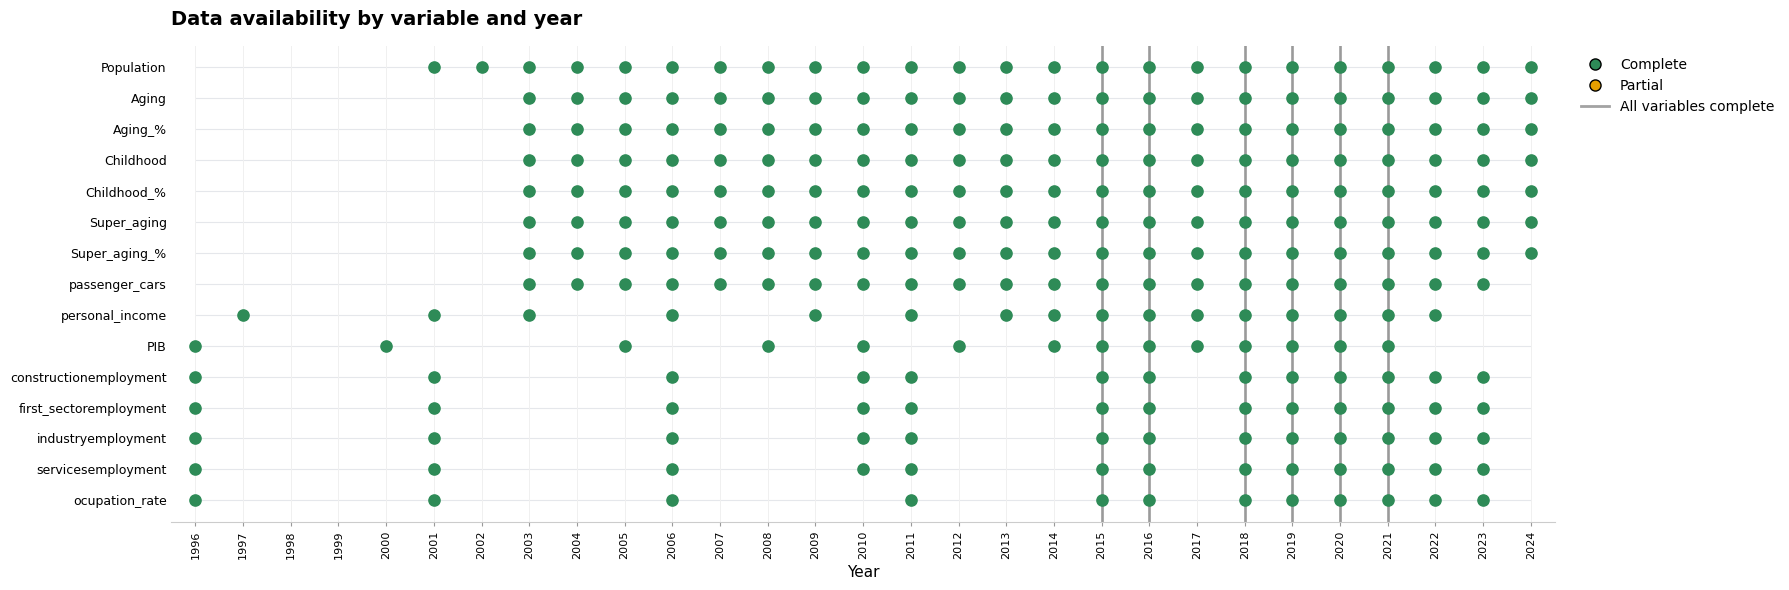

In [15]:
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------------------------------
# 1. Coverage per Variable × Year
# -------------------------------------------------------

total_municipalities = df_combined["Municipality"].nunique()

coverage = (
    df_combined.groupby(["Variable", "Year"])["Municipality"]
      .nunique()
      .reset_index(name="n_municipalities")
)

coverage["coverage_pct"] = (
    coverage["n_municipalities"] / total_municipalities * 100
)

coverage["status"] = np.where(
    coverage["coverage_pct"] == 100,
    "Complete",
    "Partial"
)

# -------------------------------------------------------
# 2. Order variables by availability
# -------------------------------------------------------

variable_order = (
    coverage.groupby("Variable")["Year"]
    .nunique()
    .sort_values(ascending=False)
    .index
    .tolist()
)

# Map variables to y positions
y_pos = {
    variable: i
    for i, variable in enumerate(variable_order)
}

# -------------------------------------------------------
# 3. Define ALL years, including years with no data
# -------------------------------------------------------

min_year = int(df_combined["Year"].min())
max_year = int(df_combined["Year"].max())

years = np.arange(min_year, max_year + 1)

# -------------------------------------------------------
# 4. Find years where ALL variables are complete
# -------------------------------------------------------

n_variables = df_combined["Variable"].nunique()

complete_years = (
    coverage[coverage["coverage_pct"] == 100]
    .groupby("Year")["Variable"]
    .nunique()
)

complete_years = complete_years[
    complete_years == n_variables
].index.tolist()

# -------------------------------------------------------
# 5. Create figure
# -------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(18, max(6, len(variable_order) * 0.4))
)

# White background
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

# -------------------------------------------------------
# 6. Horizontal line for EVERY variable
# -------------------------------------------------------

for variable, y in y_pos.items():
    ax.hlines(
        y=y,
        xmin=min_year,
        xmax=max_year,
        color="#E5E7EB",
        linewidth=0.8,
        zorder=0
    )

# -------------------------------------------------------
# 7. Vertical line for EVERY year
# -------------------------------------------------------

for year in years:
    ax.axvline(
        year,
        color="#F0F0F0",
        linewidth=0.7,
        zorder=0
    )

# -------------------------------------------------------
# 8. Plot data points
# -------------------------------------------------------

colors = {
    "Complete": "#2E8B57",   # green
    "Partial": "#E69F00"     # orange
}

for _, row in coverage.iterrows():

    ax.scatter(
        row["Year"],
        y_pos[row["Variable"]],
        color=colors[row["status"]],
        s=65,
        zorder=3
    )

# -------------------------------------------------------
# 9. Highlight years where ALL variables are complete
# -------------------------------------------------------

for year in complete_years:
    ax.axvline(
        year,
        color="#333333",
        linewidth=2,
        alpha=0.45,
        zorder=1
    )

# -------------------------------------------------------
# 10. X-axis: EVERY year
# -------------------------------------------------------

ax.set_xlim(min_year - 0.5, max_year + 0.5)
ax.set_xticks(years)
ax.set_xticklabels(
    years,
    rotation=90,
    fontsize=8
)

# -------------------------------------------------------
# 11. Y-axis
# -------------------------------------------------------

ax.set_yticks(range(len(variable_order)))
ax.set_yticklabels(
    variable_order,
    fontsize=9
)

# Put first variable at the top
ax.invert_yaxis()

# -------------------------------------------------------
# 12. Remove unnecessary borders
# -------------------------------------------------------

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)

# Keep bottom axis subtle
ax.spines["bottom"].set_color("#CCCCCC")

ax.tick_params(
    axis="y",
    length=0
)

ax.tick_params(
    axis="x",
    length=3,
    color="#999999"
)

# -------------------------------------------------------
# 13. Labels
# -------------------------------------------------------

ax.set_xlabel("Year", fontsize=11)
ax.set_ylabel("")

ax.set_title(
    "Data availability by variable and year",
    fontsize=14,
    fontweight="bold",
    loc="left",
    pad=15
)

# -------------------------------------------------------
# 14. Legend
# -------------------------------------------------------

from matplotlib.lines import Line2D

legend_elements = [
    Line2D(
        [0], [0],
        marker="o",
        color="none",
        markerfacecolor="#2E8B57",
        markersize=8,
        label="Complete"
    ),
    Line2D(
        [0], [0],
        marker="o",
        color="none",
        markerfacecolor="#E69F00",
        markersize=8,
        label="Partial"
    ),
    Line2D(
        [0], [0],
        color="#333333",
        linewidth=2,
        alpha=0.45,
        label="All variables complete"
    )
]

ax.legend(
    handles=legend_elements,
    frameon=False,
    loc="upper left",
    bbox_to_anchor=(1.01, 1)
)

plt.tight_layout()
plt.show()



6.2 Trends per variable

In [16]:
df_combined_filtered = df_combined.loc[df_combined['Year'].isin([2015, 2016, 2018, 2019, 2020, 2021])]
df_combined_pivot_filtered = df_combined_pivot.loc[df_combined_pivot['Year'].isin([2015, 2016, 2018, 2019, 2020, 2021])]

In [17]:
analyse_trends(
    df_combined_filtered,
    category="Variable",
    variables=["Value"],
    inter_perc= False
)


═════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════
  AGING
═════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════
                                                   2015                          2016                          2018                          2019                          2020                          2021
─────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Count                                                88                            88                            88                            88                      

6.3 Trends per municipality

In [18]:
analyse_trends(
    df_combined_pivot_filtered,
    category="Municipality",
    variables=["Population", "Childhood", "Aging", "PIB"],
    sort_by="Population"
)


═════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════
  DONOSTIA / SAN SEBASTIÁN
═════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════
                                                   2015                          2016                          2018                          2019                          2020                          2021
─────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Count                                          1 (1.1%)                      1 (1.1%)                      1 (1.1%)                      1 (1.1%)   


6.4 Correlation analysis

In [19]:
correlations = (
    df_combined_pivot
    .groupby("Municipality")
    .apply(lambda x: x["Population"].corr(x["Childhood"]))
)
print(correlations)
correlations.describe()

Municipality
Abaltzisketa    0.453349
Aduna           0.956663
Aia             0.954634
Aizarnazabal    0.973791
Albiztur        0.640199
                  ...   
Zerain          0.848285
Zestoa          0.978893
Zizurkil        0.891468
Zumaia          0.856745
Zumarraga       0.714018
Length: 88, dtype: float64


C:\Users\narronizari\AppData\Local\Temp\ipykernel_12876\3933408944.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x["Population"].corr(x["Childhood"]))


count    88.000000
mean      0.627715
std       0.402731
min      -0.633155
25%       0.446595
50%       0.818088
75%       0.930343
max       0.988517
dtype: float64